Author: Yashasvi Moon, email: ymoon@illinois.edu

Adapted for cosmicAI by Padma Venkatraman

# Random Forests
Random forests (RFs) are made up of many decision trees to perform a classification task. The classification chosen by majority trees is the final classification of the object. RFs have various hyperparameters that we will learn how to tune so that the RF performs better. 

The main goal is to test different hyperparameter settings and identify a configuration that performs relatively 'best' on the labelled training sample. **In this notebook, we will tune the Random Forest classifier to identify quiescent Balmer-strong (QBS) galaxies.**


## Notebook Goals

By the end of this notebook, we will:

1. Split the data into training and testing sets
2. Train a Random Forest classifier
3. Run a grid search with several hyperparameter combos on the RF to evaluate which gives best result. **Run your OWN combinations and use the model with hyperparameters that you think performs best!**
4. Evaluate model performance
5. Use your trained model to identify likely QBS candidates in a larger non-labelled catalog

## Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import os
from matplotlib import pyplot as plt
from sklearn import metrics
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import make_scorer,f1_score 
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


## Load the Labeled Dataset

We begin with the cleaned and labelled dataset created in the previous notebook.

In [ ]:
### labelled_data.csv should exist in this current directory; if it doesn't, run notebook 00.
df = pd.read_csv('labelled_dataset.csv')

## Select Features and Target Labels

The model uses photometric colors, sersic index and redshift as input features. The target label will tell us the ground truth about whether a galaxy is a QBS or not.

Think about the features carefully: remember to consider redundancy, noise features, leakage, curse of dimensionality

In [ ]:
### X contains a df with model features
X= ...

### Y contains a df with output labels
Y= ...

## Split into Training and Testing Sets

We split the labelled dataset into training and testing subsets. The training set is used for model fitting and hyperparameter tuning, while the test set is held out for final evaluation.
The `stratify` option preserves the class balance between QBS and non-QBS galaxies.

In [ ]:
### what should the test size be?
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=..., random_state=42, stratify=Y)

## Define the Scoring Metric

Because QBS galaxies are rare, overall accuracy is not the best metric. Instead, we use the F1 score for the QBS class (for the class labelled 1). F1 score is the harmonic mean of purity and completeness. We want to maximise purity of the sample (while not completely disregarding the completeness) since we do not want to waste our limited spectroscopic tools for follow-up on the less confident detections.

\begin{equation}
\rm
F1 = \frac{2 * TP}{2 * TP + FP + FN}

\end{equation}

In [5]:
my_scoring = make_scorer(f1_score, pos_label=1)

## Define the Hyperparameter Search Space

Random Forest models have several hyperparameters that affect performance, including:
1. the number of trees
2. tree depth
3. minimum samples per split and 
4. class weighting.

Here, we define a range of possible values for each hyperparameter.

#### Create various hyperparameter combinations to test out.

The definitions for each hyperparameter can be found in `scikit_learn` -> `RandomForestClassifier`

Random Forest models have several hyperparameters that affect performance, including the number of trees, tree depth, minimum samples per split, and class weighting. 

**You are encouraged to play around and change the numbers below while referring to `scikit_learn` -> `RandomForestClassifier` to understand how these play a role.**


In [ ]:
### experiment with the grid space we are searching here!
### you should also check if there are other hyperparameters we can tune here

#Number of trees
n_estimators = [100, 200, 300, 500]

#Number of features to consider at every split
max_features = ["sqrt", "log2"]

#Maximum number of levels in tree
max_depth = [10, 25, 50, 100, None]

#Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]

#Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 5, 10]

#Method of selecting samples for training each tree
bootstrap = [True, False]

#Weights associated with classes. If not given, all classes are supposed to have weight one.
class_weight = ["balanced", "balanced_subsample"]

random_grid = {
    "n_estimators": n_estimators,
    "max_features": max_features,
    "max_depth": max_depth,
    "min_samples_split": min_samples_split,
    "min_samples_leaf": min_samples_leaf,
    "bootstrap": bootstrap,
    "class_weight": class_weight
}

random_grid

{'n_estimators': [100, 200, 300, 500],
 'max_features': ['sqrt', 'log2'],
 'max_depth': [10, 25, 50, 100, None],
 'min_samples_split': [2, 5, 10],
 'min_samples_leaf': [1, 2, 5, 10],
 'bootstrap': [True, False],
 'class_weight': ['balanced', 'balanced_subsample']}

## Run Randomized Search Cross-Validation

`RandomizedSearchCV` evaluates multiple hyperparameter combinations using cross-validation on the training data. This allows us to search for better/stronger model configurations.

Change n_iter. Right now it is too small, it will only run 10 iterations with 2 cross-validations each. You do not want it to be too high either as it will take a long time to run. Discuss and come up with a reasonable number for n_iter. Can refer to `RandomizedSearchCV` in `scikit_learn`.

In [7]:
rf = RandomForestClassifier(random_state=42)
rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, 
                               n_iter = 2, cv = 2, verbose=5, 
                               random_state=42, n_jobs = -1,scoring=my_scoring)


In [8]:
rf_random.fit(x_train, y_train)

Fitting 2 folds for each of 2 candidates, totalling 4 fits
[CV 1/2] END bootstrap=False, class_weight=balanced_subsample, max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=500;, score=0.183 total time= 1.0min
[CV 2/2] END bootstrap=False, class_weight=balanced_subsample, max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=500;, score=0.184 total time= 1.0min
[CV 1/2] END bootstrap=False, class_weight=balanced, max_depth=25, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=300;, score=0.450 total time= 1.2min
[CV 2/2] END bootstrap=False, class_weight=balanced, max_depth=25, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=300;, score=0.404 total time= 1.2min


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'class_weight': ['balanced', 'balanced_subsample'], 'max_depth': [10, 25, ...], 'max_features': ['sqrt', 'log2'], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","make_scorer(f..., pos_label=1)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-valida

In [9]:
print("Best parameters found:")
print(rf_random.best_params_)

# Print the best score
print("Best score achieved:")
print(rf_random.best_score_)

Best parameters found:
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 25, 'class_weight': 'balanced', 'bootstrap': False}
Best score achieved:
0.42738686356786637


## Train the 'best' RF and evaluate
Using the best hyperparameters from the grid search, we now train the final Random Forest classifier on the training data.

In [10]:
best_rf = rf_random.best_estimator_
y_pred = best_rf.predict(x_test)
print(classification_report(y_test, y_pred, target_names=["Other", "QBS"]))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

       Other       0.99      0.98      0.98     34636
         QBS       0.49      0.59      0.54      1190

    accuracy                           0.97     35826
   macro avg       0.74      0.79      0.76     35826
weighted avg       0.97      0.97      0.97     35826

[[33901   735]
 [  485   705]]


The `best_score_` value is the average cross-validation score from the hyperparameter search. The classification report shows performance on the separate held-out test set, so the two values may differ.

## Optional: Adjust the classification threshold

By default, Random Forest predicts a galaxy as QBS when the predicted probability is greater than 0.5.
For rare astronomical objects like TDEs, we might want a stricter threshold to reduce false positives (aka increase purity). Here, we require a QBS probability greater than 0.8 or 0.7 (whatever you want) before classifying a galaxy as QBS. 

You can use some metrics like precision-recall curves to investigate the tradeoff. 

Try to find a good balance that enhances purity but does not completely ruin recall.

In [11]:
# predict QBS probabilities
y_probs = best_rf.predict_proba(x_test)[:,1]

#apply a more stricter probability threshold
y_pred_modified = (y_probs > 0.7).astype(int)
print(classification_report(y_test, y_pred_modified, target_names=["Other", "QBS"]))
print(confusion_matrix(y_test, y_pred_modified))

              precision    recall  f1-score   support

       Other       0.98      1.00      0.99     34636
         QBS       0.84      0.51      0.63      1190

    accuracy                           0.98     35826
   macro avg       0.91      0.75      0.81     35826
weighted avg       0.98      0.98      0.98     35826

[[34516   120]
 [  582   608]]


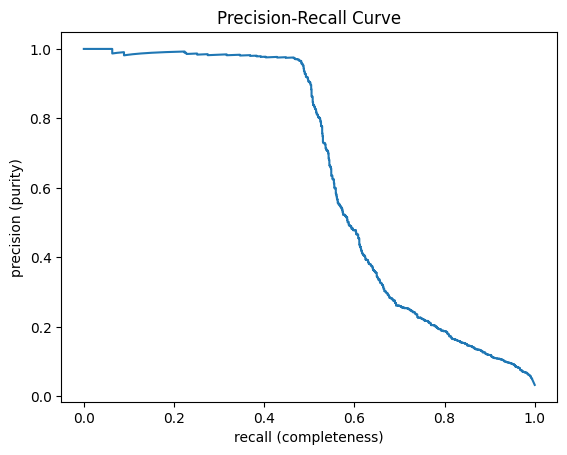

In [12]:
from sklearn.metrics import precision_recall_curve

# predict QBS probabilities
y_scores = best_rf.predict_proba(x_test)[:, 1]

#calculate precision and recall values
precision, recall, thresholds = precision_recall_curve(y_test,y_scores)

# plot the curve
plt.figure()
plt.plot(recall, precision)
plt.xlabel("recall (completeness)")
plt.ylabel("precision (purity)")
plt.title("Precision-Recall Curve")
plt.show()

## Apply the Random Forest Classifier to the Photometric Catalog

After evaluating the optimized (maybe the optional section too) of Random Forest model, we apply it to the larger photometric catalog to identify likely QBS galaxy candidates.

NOTE: This catalog contains both previously seen galaxies and galaxies without spectroscopic classifications. The classifier predicts which galaxies are likely QBS using **only** photometric information. I have already filtered this catalog and only included sources within z =0.3.

In [18]:
full_phot_catalog = pd.read_csv(os.path.join('../data', 'catalog.csv.gz'))

In [25]:
### look at what columns/features are available to build a random forest on
full_phot_catalog.columns

Index(['ls_id', 'ra', 'dec', 'mag_g', 'mag_i', 'mag_r', 'mag_z', 'mag_w1',
       'mag_w2', 'mag_w3', 'mag_w4', 'brick_primary', 'type', 'sersic',
       'z_phot_median', 'mag_g_mag_r', 'mag_r_mag_i', 'mag_i_mag_z',
       'mag_z_mag_w1', 'mag_w1_mag_w2', 'mag_w2_mag_w3'],
      dtype='str')

Here, you need to make a decision about which columns to use to classify data.
Look at the columns in the catalog, look at correlations, try different combinations. Think about what makes intuitive sense -- if we want to find quiescent balmer strong galaxies using their *colors*, which properties should we use?

In [ ]:
list_of_interesting_properties = [...]
X_catalog= full_phot_catalog[list_of_interesting_properties]

In [20]:
Y_pred_catalog = best_rf.predict(X_catalog)
# You can also increase prob thresholds here if you want! 
# but be consistent with what you did earlier 


In [22]:
Y_pred_catalog

array([0, 0, 0, ..., 0, 0, 0], shape=(5832189,))

In [ ]:
# Visualize in a neat dataframe which objects are marked QBS in the big catalog
QBS_RF = full_phot_catalog[Y_pred_catalog== 1][[...]]
display(QBS_RF)

,ls_id,ra,dec,mag_g,mag_r,mag_i,mag_z,mag_w1,mag_w2,mag_w3,z_phot_median,sersic
282,10995245824085389,326.543899,-38.892714,18.595377,17.553015,17.121649,16.838802,16.856890,17.220972,16.582401,0.163968,3.020516
287,10995245824086092,326.596141,-38.925112,16.433252,15.814985,15.575833,15.405256,15.747445,16.279089,19.272156,0.030174,6.000000
293,10995245825131365,326.679679,-38.929361,17.481428,16.805704,16.510172,16.312086,16.626328,17.181267,16.245665,0.055986,6.000000
434,10995249379805223,327.123315,-38.228015,19.379951,18.345024,17.924738,17.646713,17.741383,18.117320,17.250233,0.174325,3.391052
491,10995249380854258,327.476408,-38.371131,19.270807,18.399115,18.044660,17.808582,18.020576,18.514517,18.325750,0.108562,2.799582
...,...,...,...,...,...,...,...,...,...,...,...,...
5831084,10995254438136023,45.064096,-36.987171,16.623880,15.837661,15.502041,15.287808,15.670446,16.216576,16.634565,0.042661,4.884088
5831100,10995254437091745,44.884756,-36.941133,18.542389,17.408821,16.976921,16.691437,16.686419,16.984467,16.348097,0.198437,4.909441
5831240,10995256859297670,45.063354,-36.578605,17.004908,16.186546,15.857821,15.630157,15.967386,16.426142,16.431263,0.065000,6.000000
5831740,10995260525121068,45.876250,-35.770036,19.760777,18.737839,18.387781,18.192620,18.178087,18.522104,17.963640,0.208526,4.428145


Now, make a corner plot with the properties of all the galaxies in the catalog, the QBS selected galaxies. Is there a particular part of parameter space where these galaxies lie? Are there other techniques we can use to isolate this space?

In [27]:
# make an overlaid corner plot of all galaxies vs QBF galaxies

**Yay! You have successfully created your own RF and optimized its hyperparameters. Additionally, you have also used your RF to find likely QBS galaxies in a unlabelled photometric sample. Great job!**